In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef, make_scorer

In [2]:
import pickle
with open('list_groups_2.pkl', 'rb') as f:
    list_groups = pickle.load(f)
data_log2 = pd.read_pickle('data_log2_Lisbon.pkl')

In [3]:
data_log2

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00533,O14498,O14594,O14773,O15394,O43505,O75144,...,Q9P2S2,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,8.008485,7.884580,7.046524,9.502615,6.808836,6.264486,6.706240,8.666203,11.235021,10.433533,...,8.163801,11.983824,7.474387,7.673846,6.288357,6.569209,8.519585,8.721916,6.428503,9.765251
LIS098,8.408618,8.316675,6.742249,9.214086,6.607503,5.651112,6.832662,8.234889,11.566791,10.476068,...,7.954033,11.609941,7.249929,7.780402,6.187722,6.248402,8.200359,8.767165,6.877487,8.354624
LIS017,6.710379,7.121647,6.803782,9.288289,6.816740,6.544420,6.978630,8.426206,11.710423,9.890181,...,8.006769,11.674201,7.640505,8.166806,5.968895,6.599523,8.233011,8.527669,7.343052,7.835937
LIS007,10.421655,9.388187,7.020158,8.407935,7.345618,4.951625,6.082505,8.008798,10.026012,11.312299,...,6.808102,10.691421,7.316173,7.842388,7.781714,6.443365,6.264730,7.430227,6.817291,9.228949
LIS026,8.605772,8.765760,7.234664,9.194671,6.489169,6.035030,6.804389,8.621330,11.018047,10.837123,...,7.335810,11.564264,7.439665,8.143383,7.001780,6.322777,8.011177,8.391046,6.702228,8.845537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS102,8.583207,7.473089,7.144108,9.710235,7.141964,7.286142,6.577400,8.624346,12.354748,9.557963,...,8.412790,11.306529,7.106997,7.976610,6.025791,6.078200,8.961421,9.106806,6.697260,9.566731
LIS103,8.504410,9.427137,6.745062,8.539744,7.318733,5.619750,6.116679,8.008053,11.802823,9.665352,...,7.313518,10.799476,7.207493,7.716394,6.032231,5.496488,8.011059,8.241826,6.325904,10.136773
LIS104,8.838303,8.791313,7.131044,8.249825,6.895412,6.168939,6.442655,8.151280,11.133271,9.921353,...,7.347630,10.902805,7.470407,7.936497,6.393099,6.199994,7.690033,7.994908,6.444203,10.341875
LIS116,10.749107,8.583583,7.019946,7.900897,6.739943,5.874352,6.118279,8.195874,11.042596,9.845702,...,6.489773,10.191849,7.128634,8.297292,6.040358,5.941968,6.786884,7.390092,6.811073,10.435931


In [4]:
list_groups = pd.Series(list_groups)

In [5]:
'''
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold

# ======================
# DATA SETUP
# ======================
X = data_log2.copy()
y = np.array(list_groups)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# EXPERIMENT PARAMETERS
# ======================
k_values = [5, 10, 15, 20]
seeds = range(5)
all_k_results = []

print("Starting Sensitivity Analysis for K-features...")

# ======================
# OUTER LOOP: K-VALUES
# ======================
for k in k_values:
    k_seeds_mcc = []
    k_seeds_auc = []
    k_feature_union = set()

    print(f"\nTesting K = {k} proteins...")

    for seed in seeds:
        # 1. Split 70/30
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, stratify=y, random_state=seed
        )
        y_test_bin = (y_test == "MCI-AD").astype(int)

        # 2. Simple Feature Importance (5-Fold CV on Train only)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        fold_importances = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_sub, y_sub = X_train.iloc[train_idx], y_train[train_idx]
            rf_fs = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=seed)
            rf_fs.fit(X_sub, y_sub)
            fold_importances.append(rf_fs.feature_importances_)

        # Average importance and Ranking
        mean_imp = np.mean(fold_importances, axis=0)
        ranking = pd.DataFrame({"protein": X.columns, "imp": mean_imp}).sort_values("imp", ascending=False)
        
        # Select Top-K
        top_features = ranking["protein"].iloc[:k].tolist()
        k_feature_union.update(top_features)

        # 3. Final Model Evaluation
        rf_final = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42)
        rf_final.fit(X_train[top_features], y_train)

        # Predictions
        y_pred = rf_final.predict(X_test[top_features])
        ad_idx = np.where(rf_final.classes_ == "MCI-AD")[0][0]
        y_prob = rf_final.predict_proba(X_test[top_features])[:, ad_idx]

        k_seeds_mcc.append(matthews_corrcoef(y_test, y_pred))
        k_seeds_auc.append(roc_auc_score(y_test_bin, y_prob))

    # Save aggregated results for this K
    res = {
        "K": k,
        "mean_mcc": np.mean(k_seeds_mcc),
        "std_mcc": np.std(k_seeds_mcc),
        "mean_auc": np.mean(k_seeds_auc),
        "std_auc": np.std(k_seeds_auc),
        "union_size": len(k_feature_union)
    }
    all_results.append(res)
    
    # INDIVIDUAL REPORT FOR EACH K
    print(f"--- REPORT FOR K={k} ---")
    print(f"Mean MCC: {res['mean_mcc']:.3f} (±{res['std_mcc']:.3f})")
    print(f"Mean AUC: {res['mean_auc']:.3f} (±{res['std_auc']:.3f})")
    print(f"Total Unique Proteins in Union: {res['union_size']}")

# ======================
# FINAL COMPARISON TABLE
# ======================
df_final = pd.DataFrame(all_results)
print("\n" + "="*50)
print("FINAL SENSITIVITY ANALYSIS SUMMARY")
print("="*50)
print(df_final[["K", "mean_mcc", "mean_auc", "union_size"]].to_string(index=False))
'''

'\nimport numpy as np\nimport pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import matthews_corrcoef, roc_auc_score\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\n\n# ======================\n# DATA SETUP\n# ======================\nX = data_log2.copy()\ny = np.array(list_groups)\ny_binary = (y == "MCI-AD").astype(int)\n\n# ======================\n# EXPERIMENT PARAMETERS\n# ======================\nk_values = [5, 10, 15, 20]\nseeds = range(5)\nall_k_results = []\n\nprint("Starting Sensitivity Analysis for K-features...")\n\n# ======================\n# OUTER LOOP: K-VALUES\n# ======================\nfor k in k_values:\n    k_seeds_mcc = []\n    k_seeds_auc = []\n    k_feature_union = set()\n\n    print(f"\nTesting K = {k} proteins...")\n\n    for seed in seeds:\n        # 1. Split 70/30\n        X_train, X_test, y_train, y_test = train_test_split(\n            X, y, test_size=0.3, stratify=y, random_state=seed\n        )\n 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score

# ======================
# DATI
# ======================
X = data_log2.copy()
y = np.array(list_groups)

# binarizza per AUC (importante!)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# PARAMETRI GLOBALI
# ======================
thresholds = [ 0.7, 0.8, 0.9]
n_iterations = 20
seeds = range(15)

# ======================
# STORAGE
# ======================
all_results = []
feature_counter = {}
threshold_counter = {}

# ======================
# BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]

    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)

    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)

    return X.iloc[indices], y[indices]


# ======================
# LOOP SEED
# ======================
for seed in seeds:

    print(f"\n===== SEED {seed} =====")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    y_train_bin = (y_train == "MCI-AD").astype(int)
    y_test_bin = (y_test == "MCI-AD").astype(int)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    threshold_scores = []

    # ======================
    # CV per scegliere threshold
    # ======================
    for t in thresholds:

        fold_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):

            X_subtrain = X_train.iloc[train_idx]
            y_subtrain = y_train[train_idx]

            X_val = X_train.iloc[val_idx]
            y_val = y_train[val_idx]

            y_val_bin = (y_val == "MCI-AD").astype(int)

            # ===== bootstrap importance
            feature_names = X_subtrain.columns
            importance_matrix = np.zeros((n_iterations, len(feature_names)))

            for i in range(n_iterations):

                X_boot, y_boot = stratified_bootstrap(X_subtrain, y_subtrain)

                rf = RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=seed
                )

                rf.fit(X_boot, y_boot)
                importance_matrix[i] = rf.feature_importances_

            mean_importance = importance_matrix.mean(axis=0)

            ranking_df = pd.DataFrame({
                "protein": feature_names,
                "importance": mean_importance
            }).sort_values("importance", ascending=False)

            # normalizzazione
            ranking_df["importance"] /= ranking_df["importance"].sum()
            ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

            # selezione feature
            selected_features = ranking_df[
                ranking_df["cum_importance"] <= t
            ]["protein"]

            if len(selected_features) == 0:
                selected_features = ranking_df["protein"].iloc[:1]

            # train modello
            rf = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=seed
            )

            rf.fit(X_subtrain[selected_features], y_subtrain)

            # valutazione
            y_pred = rf.predict(X_val[selected_features])
            mcc = matthews_corrcoef(y_val, y_pred)

            fold_scores.append(mcc)

        threshold_scores.append(np.mean(fold_scores))

    # ======================
    # best threshold
    # ======================
    best_threshold = thresholds[np.argmax(threshold_scores)]
    print("Best threshold:", best_threshold)

    # ======================
    # TRAIN FINALE (su tutto train)
    # ======================
    feature_names = X_train.columns
    importance_matrix = np.zeros((n_iterations, len(feature_names)))

    for i in range(n_iterations):

        X_boot, y_boot = stratified_bootstrap(X_train, y_train)

        rf = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            n_jobs=-1,
            random_state=i
        )

        rf.fit(X_boot, y_boot)
        importance_matrix[i] = rf.feature_importances_

    mean_importance = importance_matrix.mean(axis=0)

    ranking_df = pd.DataFrame({
        "protein": feature_names,
        "importance": mean_importance
    }).sort_values("importance", ascending=False)

    ranking_df["importance"] /= ranking_df["importance"].sum()
    ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

    top_features = ranking_df[
        ranking_df["cum_importance"] <= best_threshold
    ]["protein"]

    if len(top_features) == 0:
        top_features = ranking_df["protein"].iloc[:1]

    print("Numero feature:", len(top_features))

    # ======================
    # TEST
    # ======================
    rf_final = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    )

    rf_final.fit(X_train[top_features], y_train)

    y_pred = rf_final.predict(X_test[top_features])
    class_order = rf_final.classes_
    ad_index = np.where(class_order == "MCI-AD")[0][0]
    
    y_prob = rf_final.predict_proba(X_test[top_features])[:, ad_index]

    test_mcc = matthews_corrcoef(y_test, y_pred)
    test_auc = roc_auc_score(y_test_bin, y_prob)
    print("Class order:", rf_final.classes_)
    print("Test MCC:", test_mcc)
    print("Test AUC:", test_auc)

    # ======================
    # SALVATAGGIO
    # ======================
    all_results.append({
        "model": "RF",
        "seed": seed,
        "mcc": test_mcc,
        "auc": test_auc,
        "n_features": len(top_features),
        "best_threshold": best_threshold
    })

    # frequenza feature
    for f in top_features:
        feature_counter[f] = feature_counter.get(f, 0) + 1

    # frequenza threshold
    threshold_counter[best_threshold] = threshold_counter.get(best_threshold, 0) + 1


# ======================
# RISULTATI FINALI
# ======================
df_results = pd.DataFrame(all_results)

print("\n===== FINAL RESULTS =====")
print("Mean MCC:", df_results["mcc"].mean())
print("Mean AUC:", df_results["auc"].mean())

# frequenze
feature_freq = pd.Series(feature_counter).sort_values(ascending=False) / len(seeds)
threshold_freq = pd.Series(threshold_counter).sort_index() / len(seeds)

print("\nTop features (frequency):")
print(feature_freq.head(20))

print("\nThreshold frequency:")
print(threshold_freq)


===== SEED 0 =====
Best threshold: 0.9
Numero feature: 132
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.6888888888888889
Test AUC: 0.8888888888888888

===== SEED 1 =====
Best threshold: 0.7
Numero feature: 56
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.6888888888888889
Test AUC: 0.9333333333333333

===== SEED 2 =====
Best threshold: 0.7
Numero feature: 67
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 3 =====
Best threshold: 0.7
Numero feature: 56
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8606629658238705
Test AUC: 0.9777777777777779

===== SEED 4 =====
Best threshold: 0.7
Numero feature: 57
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.848528137423857
Test AUC: 1.0

===== SEED 5 =====
Best threshold: 0.9
Numero feature: 142
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.848528137423857
Test AUC: 1.0

===== SEED 6 =====
Best threshold: 0.8
Numero feature: 86
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.7006490497453707
Test AUC: 1.0

===== SEED 7 =====
Best 

In [7]:
feature_freq.to_pickle('feature_rf_Lisbon.pkl')

In [8]:
df_results = pd.DataFrame(all_results)
df_results.to_pickle('results_Lisbon_rf.pkl')

In [9]:
len(feature_freq)

170

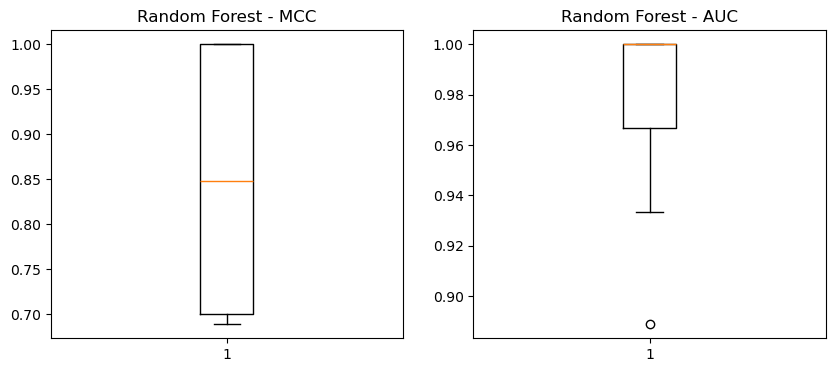

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df_results["mcc"])
plt.title("Random Forest - MCC")

plt.subplot(1,2,2)
plt.boxplot(df_results["auc"])
plt.title("Random Forest - AUC")

plt.show()

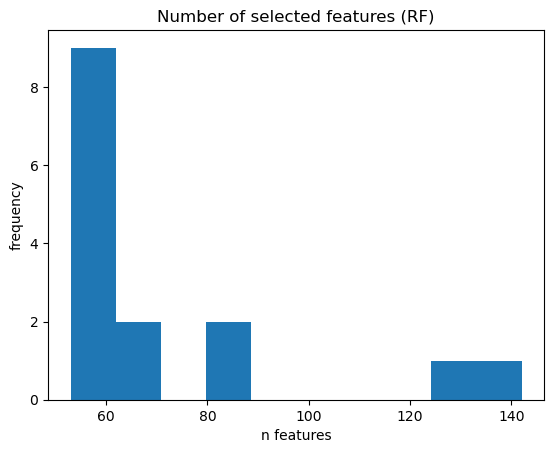

In [11]:
plt.figure()
plt.hist(df_results["n_features"], bins=10)
plt.title("Number of selected features (RF)")
plt.xlabel("n features")
plt.ylabel("frequency")
plt.show()

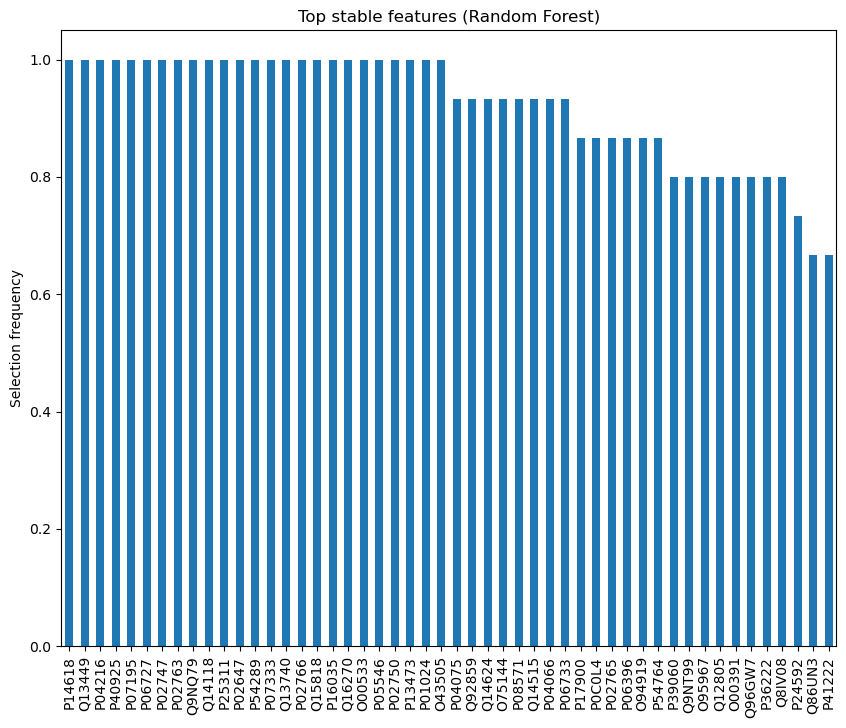

In [12]:
feature_freq_sorted = feature_freq.sort_values(ascending=False)

plt.figure(figsize=(10,8))
feature_freq_sorted.head(50).plot(kind="bar")
plt.title("Top stable features (Random Forest)")
plt.ylabel("Selection frequency")
plt.show()